```markdown
# Scientific Article Program Description

This notebook performs an iterative extraction of series resistance (Rs) and ideality factor (n) from current-voltage (I-V) characteristics of a diode, based on the method proposed by Cheung and Cheung. It calculates key diode parameters, including the saturation current (I0) and barrier height (Phi_B). The program compares Cheung, Norde, and our method (OY) as well. The process involves:
1.  **Data Upload**: Uploading multiple I-V CSV files.
2.  **Iterative Extraction**: Applying an iterative algorithm to determine Rs and n for each I-V curve.
3.  **Parameter Calculation**: Calculating I0 and Phi_B using the extracted parameters.
4.  **Data Visualization**: Generating individual and combined plots of ln(Rs) vs. Voltage.
5.  **Summary Generation**: Compiling all extracted parameters into a comprehensive summary table.
6.  **Export and Download**: Exporting all results (adjusted I-V data, ln(Rs) data, plots, and the summary table) for further analysis.

The code is designed for batch processing of multiple experimental datasets, providing a streamlined approach to characterizing semiconductor devices.
```

Environment ready
Parameters set


Saving IV_100mW.csv to IV_100mW.csv
1 files uploaded


Processing files: 100%|██████████| 1/1 [00:00<00:00,  3.87it/s]


===== Summary =====


,File,Ideality factor (n),Saturation current I0 (A),Barrier height Phi_B (eV)
0,IV_100mW.csv,10.939201,2.578474e-08,0.710931


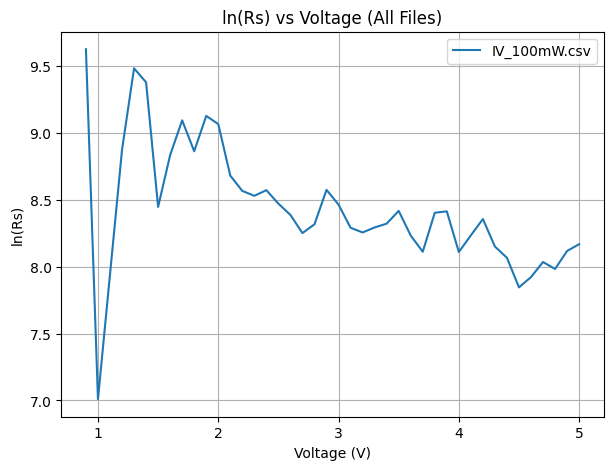

Excel file created: IV_summary.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download complete


In [ ]:
# =========================================================
# CELL 1: INSTALL + IMPORTS
# =========================================================

# Program: Diode I-V Characterization and Parameter Extraction
# Author: Ocaya, R.O.
# Date: May 29, 2026
# Open-source for educational usage.
# This work is licensed under a Creative Commons Attribution 4.0 International License (CC BY 4.0).
# You are free to share and adapt the work, provided appropriate credit is given.
# For details, visit: https://creativecommons.org/licenses/by/4.0/
# This program performs an iterative extraction of series resistance (Rs) and ideality factor (n)
# from current-voltage (I-V) characteristics of a diode, based on the method proposed by Cheung and Cheung.
# It also compares the results with Norde and our method (OY).
# It calculates key diode parameters, including the saturation current (I0) and barrier height (Phi_B).
# The code is designed for batch processing of multiple experimental datasets.

!pip install openpyxl tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from google.colab import files
import io
import glob

print("Environment ready")

# 2: USER PARAMETERS (EDITABLE)
# =========================================================
T = 300.0          # Temperature (K)
A_star = 32        # Richardson constant (A/cm^2 K^2)
A = 7.854e-3       # Device area (cm^2)

iterations = 15
current_threshold = 1e-10

print("Parameters set")
# =========================================================
# CELL 3: UPLOAD MULTIPLE CSV FILES
# =========================================================
uploaded = files.upload()

file_data = {}
for filename, content in uploaded.items():
    file_data[filename] = pd.read_csv(io.BytesIO(content), header=None)

print(f"{len(file_data)} files uploaded")
# =========================================================
# CELL 4: CORE EXTRACTION FUNCTION (YOUR MODEL)
# =========================================================
def process_iv(df, T, A_star, A, iterations, current_threshold):
    k = 1.380649e-23
    q = 1.602176634e-19

    I = df.iloc[:, 0].values
    V = df.iloc[:, 1].values

    # Sort data
    idx = np.argsort(V)
    V, I = V[idx], I[idx]

    n = 2.0

    for _ in range(iterations):
        dV = np.gradient(V)
        dI = np.gradient(I)
        dVdI = dV / dI

        Rs = dVdI - (n * k * T) / (q * np.where(I != 0, I, np.nan))
        Vj = V - I * Rs

        mask = (I > current_threshold) & (Vj > 0)
        if np.sum(mask) < 3:
            continue

        Vjf = Vj[mask]
        If = I[mask]

        slope, intercept = np.polyfit(Vjf, np.log(If), 1)
        n = q / (k * T * slope)

    I0 = np.exp(intercept)
    Phi_B = (k * T / q) * np.log((A_star * A * T**2) / I0)

    return V, I, Vj, Rs, n, I0, Phi_B
# =========================================================
# CELL 5: BATCH PROCESSING
# =========================================================
results_summary = []
all_curves = []

for filename in tqdm(file_data.keys(), desc="Processing files"):
    df = file_data[filename]

    V, I, Vj, Rs, n, I0, Phi_B = process_iv(
        df, T, A_star, A, iterations, current_threshold
    )

    base = filename.replace(".csv", "")

    # Save adjusted IV data
    adjusted_df = pd.DataFrame({
        "Voltage (V)": V,
        "Current (A)": I,
        "Adjusted Voltage Vj (V)": Vj,
        "Series Resistance Rs (Ohm)"
: Rs
    })
    adjusted_df.to_csv(f"{base}_adjusted_IV.csv", index=False)

    # Save ln(Rs)
    mask = (Rs > 0) & np.isfinite(Rs)
    V_plot = V[mask]
    Rs_plot = Rs[mask]

    logRs_df = pd.DataFrame({
        "Voltage (V)": V_plot,
        "ln(Rs)": np.log(Rs_plot)
    })
    logRs_df.to_csv(f"{base}_logRs.csv", index=False)

    # Save plot
    plt.figure()
    plt.plot(V_plot, np.log(Rs_plot), 'o', markersize=3)
    plt.xlabel("Voltage (V)")
    plt.ylabel("ln(Rs)")
    plt.title(f"ln(Rs) vs V ({base})")
    plt.grid()
    plt.savefig(f"{base}_logRs.png", dpi=300)
    plt.close()

    # Store for combined plots
    all_curves.append((filename, V_plot, Rs_plot))

    # Summary data
    results_summary.append({
        "File": filename,
        "Ideality factor (n)": n,
        "Saturation current I0 (A)": I0,
        "Barrier height Phi_B (eV)": Phi_B
    })

summary_df = pd.DataFrame(results_summary)
print("\n===== Summary ====")
display(summary_df)

# =========================================================
# CELL 6: COMBINED INTERACTIVE PLOT
# =========================================================
plt.figure(figsize=(7,5))

for filename, Vp, Rs_p in all_curves:
    plt.plot(Vp, np.log(Rs_p), label=filename)

plt.xlabel("Voltage (V)")
plt.ylabel("ln(Rs)")
plt.title("ln(Rs) vs Voltage (All Files)")
plt.legend()
plt.grid()

plt.show()
# =========================================================
# CELL 7: EXPORT SUMMARY TO EXCEL
# =========================================================
summary_file = "IV_summary.xlsx"

with pd.ExcelWriter(summary_file, engine='openpyxl') as writer:
    summary_df.to_excel(writer, index=False, sheet_name="Summary")

print("Excel file created:", summary_file)
# =========================================================
# CELL 8: DOWNLOAD ALL OUTPUT FILES
# =========================================================
files_to_download = glob.glob("*.csv") + glob.glob("*.png") + ["IV_summary.xlsx"]

for f in files_to_download:
    files.download(f)

print("Download complete")